Projet de Finance Empirique sur les trois ETFs suivants :


*   SPYX
*   CLIM
*   INRG

Emeline Lavaux et Pauline Dumas





In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

Exercice 1

Représentation graphique de l'évolution de la valeur de nos ETFs

In [21]:
# Nous affichons les premières lignes de chaque document afin de vérifier que l'ouverture des fichiers se fait bien.

# Pour SPYX :
data_spx = pd.read_csv('/Données historiques SPYX.csv')
print(data_spx.head())
print(data_spx.columns)

# Pour CLIM :
data_clim = pd.read_csv('/Données historiques CLIM.csv')
print(data_clim.head())
print(data_clim.columns)

# Pour INRG :

data_inrg = pd.read_csv('/Données historiques INRG.csv')
print(data_inrg.head())
print(data_inrg.columns)

         Date Dernier   Ouv.  Plus Haut Plus Bas     Vol. Variation %
0  15/12/2024   48,77  49,79      49,95    47,88  473,19K      -1,73%
1  08/12/2024   49,63  49,91      49,97    49,47  459,71K      -0,56%
2  01/12/2024   49,91  49,49      50,01    49,41  457,02K       0,95%
3  24/11/2024   49,44  49,15      49,50    48,85  330,45K       1,29%
4  17/11/2024   48,81  48,01      48,85    47,89  649,65K       1,71%
Index(['Date', 'Dernier', 'Ouv.', ' Plus Haut', 'Plus Bas', 'Vol.',
       'Variation %'],
      dtype='object')
         Date Dernier   Ouv.  Plus Haut Plus Bas    Vol. Variation %
0  15/12/2024   49,24  49,30      49,49    49,06   8,46K      -0,33%
1  08/12/2024   49,41  49,95      49,95    49,31   4,72K      -0,73%
2  01/12/2024   49,77  49,64      49,82    49,62   9,16K       0,31%
3  24/11/2024   49,62  49,14      49,62    49,12   8,31K       0,99%
4  17/11/2024   49,13  48,85      49,13    48,68  10,55K       0,75%
Index(['Date', 'Dernier', 'Ouv.', ' Plus Haut', 'Plus

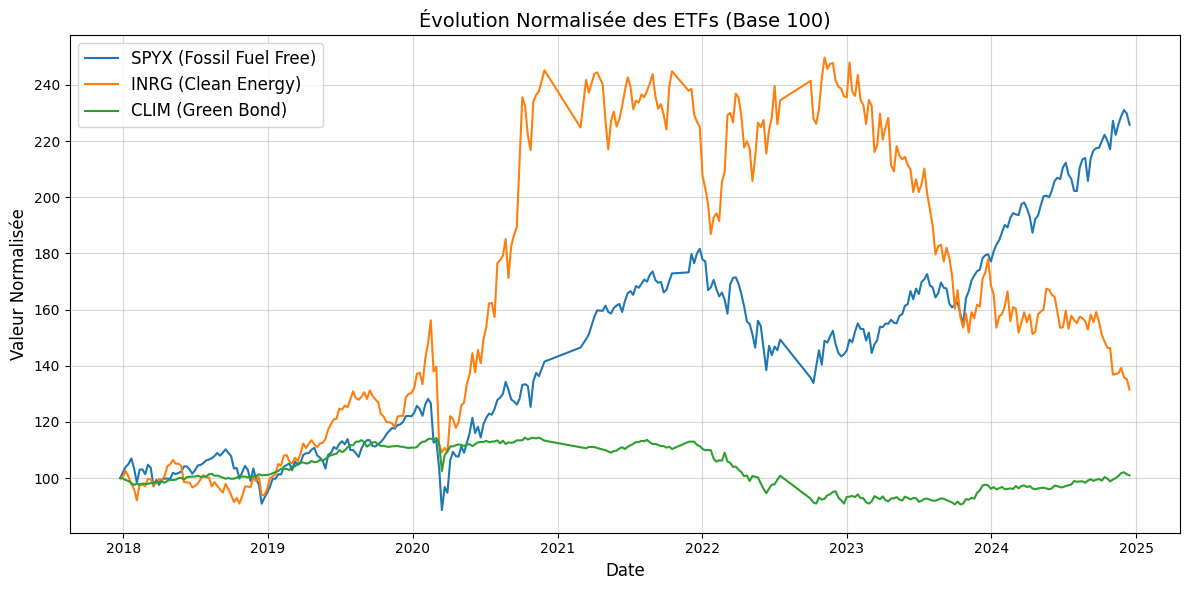

In [22]:
# Nous créons une fonction pour charger correctement les données de chaque ETF (ransformer la date au bon format, vérifier les valeurs nuémriques, enlever les valeurs manquantes..):
def normalize_etf_data(file_path, column_name, etf_name):
    data = pd.read_csv(file_path)
    data.columns = data.columns.str.strip()
    data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
    data[column_name] = data[column_name].str.replace(',', '.').str.strip()
    data[column_name] = pd.to_numeric(data[column_name], errors='coerce')
    data = data.dropna(subset=[column_name])
    data = data.sort_values('Date')
    if data.empty:
        raise ValueError(f"Les données de la colonne '{column_name}' sont vides après le nettoyage. Vérifiez {file_path}.")

    # Nous normalisons la valeur initiale à 100 :
    data['Normalized Value'] = (data[column_name] / data[column_name].iloc[0]) * 100
    return data[['Date', 'Normalized Value']].rename(columns={'Normalized Value': etf_name})

# Ouverture et normalisation des données de nos trois ETFs :
try:
    spx_data = normalize_etf_data('/Données historiques SPYX.csv', 'Dernier', 'SPYX')
    inrg_data = normalize_etf_data('/Données historiques INRG.csv', 'Dernier', 'INRG')
    clim_data = normalize_etf_data('/Données historiques CLIM.csv', 'Dernier', 'CLIM')
except ValueError as e:
    print(e)
    raise

# Nous fusionnons les trois DataFrames sur la colonne Date :
merged_data = spx_data.merge(inrg_data, on='Date', how='inner').merge(clim_data, on='Date', how='inner')

# Puis nous traçons les 3 ETFs sur le même graphique :
plt.figure(figsize=(12, 6))
plt.plot(merged_data['Date'], merged_data['SPYX'], label='SPYX (Fossil Fuel Free)')
plt.plot(merged_data['Date'], merged_data['INRG'], label='INRG (Clean Energy)')
plt.plot(merged_data['Date'], merged_data['CLIM'], label='CLIM (Green Bond)')

# Nous configurons la mise en page du graphique
plt.title('Évolution Normalisée des ETFs (Base 100)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Valeur Normalisée', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.tight_layout()

plt.show()

Exercice 2

a. Calcul des statistiques descriptives des rendements :

In [23]:
# Nous commençons par définir une fonction pour calculer les rendements géométriques :
def calculate_log_returns(data, etf_name):
    data[f'{etf_name}_Log_Returns'] = np.log(data[etf_name] / data[etf_name].shift(1))
    return data.dropna()

# Puis nous calculons les rendements géométriques pour chaque ETF :
merged_data = calculate_log_returns(merged_data, 'SPYX')
merged_data = calculate_log_returns(merged_data, 'INRG')
merged_data = calculate_log_returns(merged_data, 'CLIM')

# Ensuite on créé une fonction pour calculer les statistiques descriptives :
def descriptive_stats(data, column_name):
    stats = {
        'Moyenne': data[column_name].mean(),
        'Médiane': data[column_name].median(),
        'Écart-Type': data[column_name].std(),
        'Skewness': data[column_name].skew(),
        'Kurtosis': data[column_name].kurt(),
        'Minimum': data[column_name].min(),
        'Maximum': data[column_name].max()
    }
    return pd.Series(stats)

# Nous pouvons calculer les statistiques descriptives pour chaque ETF :
spx_stats = descriptive_stats(merged_data, 'SPYX_Log_Returns')
inrg_stats = descriptive_stats(merged_data, 'INRG_Log_Returns')
clim_stats = descriptive_stats(merged_data, 'CLIM_Log_Returns')

# Nous regroupons toutes les statistiques dans un tableau
stats_summary = pd.DataFrame({
    'SPYX': spx_stats,
    'INRG': inrg_stats,
    'CLIM': clim_stats
})

print("Statistiques descriptives des rendements géométriques hebdomadaires :")
print(stats_summary)

# Nous téléchargons le fichier pour l'ajouter à notre projet :
stats_summary.to_csv('statistiques_descriptives_rendements.csv', index=True, float_format='%.6f')
from google.colab import files
files.download('statistiques_descriptives_rendements.csv')

Statistiques descriptives des rendements géométriques hebdomadaires :
                SPYX      INRG       CLIM
Moyenne     0.002341  0.000752   0.000051
Médiane     0.005293  0.001331   0.000726
Écart-Type  0.026741  0.035784   0.010884
Skewness   -0.917597 -0.606554  -2.895084
Kurtosis    6.119345  4.890205  27.214145
Minimum    -0.156387 -0.221579  -0.091885
Maximum     0.114793  0.114689   0.054130


<ipython-input-23-04d9522318eb>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[f'{etf_name}_Log_Returns'] = np.log(data[etf_name] / data[etf_name].shift(1))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Enfin, nous calculons le rendement annualisé :
def annualized_return(weekly_mean):
    return (1 + weekly_mean)**52 - 1

spx_annualized = annualized_return(spx_stats['Moyenne'])
inrg_annualized = annualized_return(inrg_stats['Moyenne'])
clim_annualized = annualized_return(clim_stats['Moyenne'])

print(f"Rendement annualisé - SPYX : {spx_annualized:.2%}")
print(f"Rendement annualisé - INRG : {inrg_annualized:.2%}")
print(f"Rendement annualisé - CLIM : {clim_annualized:.2%}")

# Nous téléchargons le fichier afin de l'ajouter à notre dossier :
annualized_returns = pd.DataFrame({
    'ETF': ['SPYX', 'INRG', 'CLIM'],
    'Rendement Annualisé': [spx_annualized, inrg_annualized, clim_annualized]
})

annualized_returns.to_csv('rendements_annualises.csv', index=False, float_format='%.6f')
from google.colab import files
files.download('rendements_annualises.csv')

Rendement annualisé - SPYX : 12.93%
Rendement annualisé - INRG : 3.99%
Rendement annualisé - CLIM : 0.27%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

b. Histogramme de la distribution, graphique QQ et test de normalité de Jarque-Bera

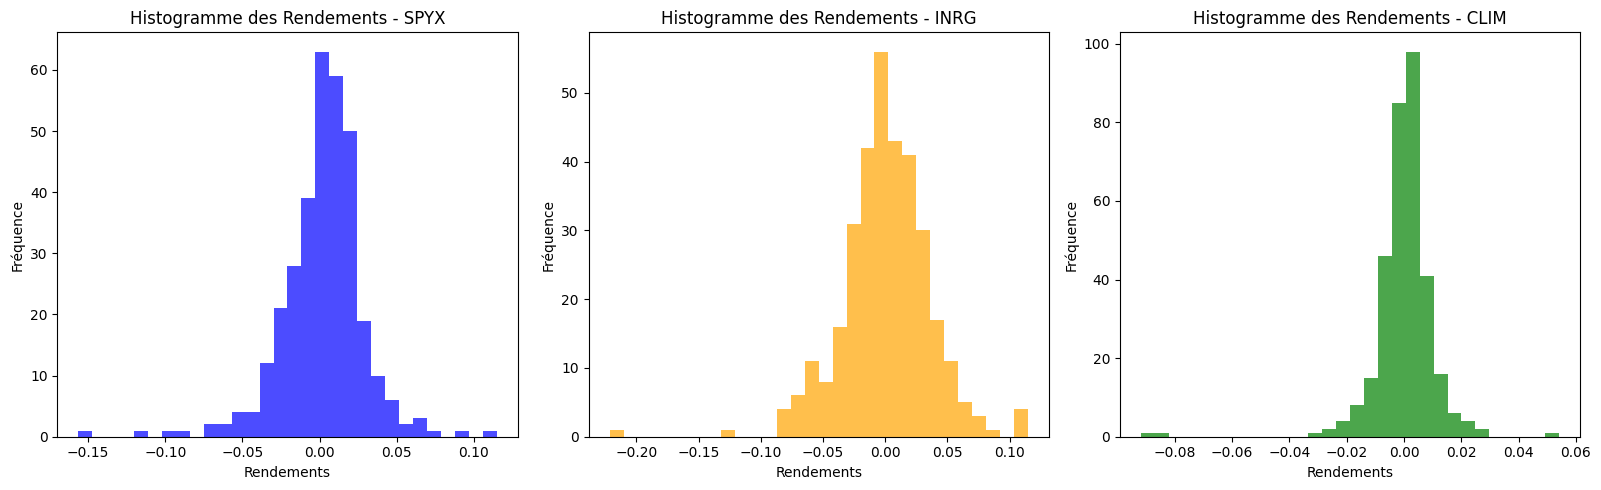

In [26]:
# Visualisation des rendements par un histogramme par ETF :
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.hist(merged_data['SPYX_Log_Returns'], bins=30, color='blue', alpha=0.7)
plt.title('Histogramme des Rendements - SPYX')
plt.xlabel('Rendements')
plt.ylabel('Fréquence')

plt.subplot(1, 3, 2)
plt.hist(merged_data['INRG_Log_Returns'], bins=30, color='orange', alpha=0.7)
plt.title('Histogramme des Rendements - INRG')
plt.xlabel('Rendements')
plt.ylabel('Fréquence')

plt.subplot(1, 3, 3)
plt.hist(merged_data['CLIM_Log_Returns'], bins=30, color='green', alpha=0.7)
plt.title('Histogramme des Rendements - CLIM')
plt.xlabel('Rendements')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

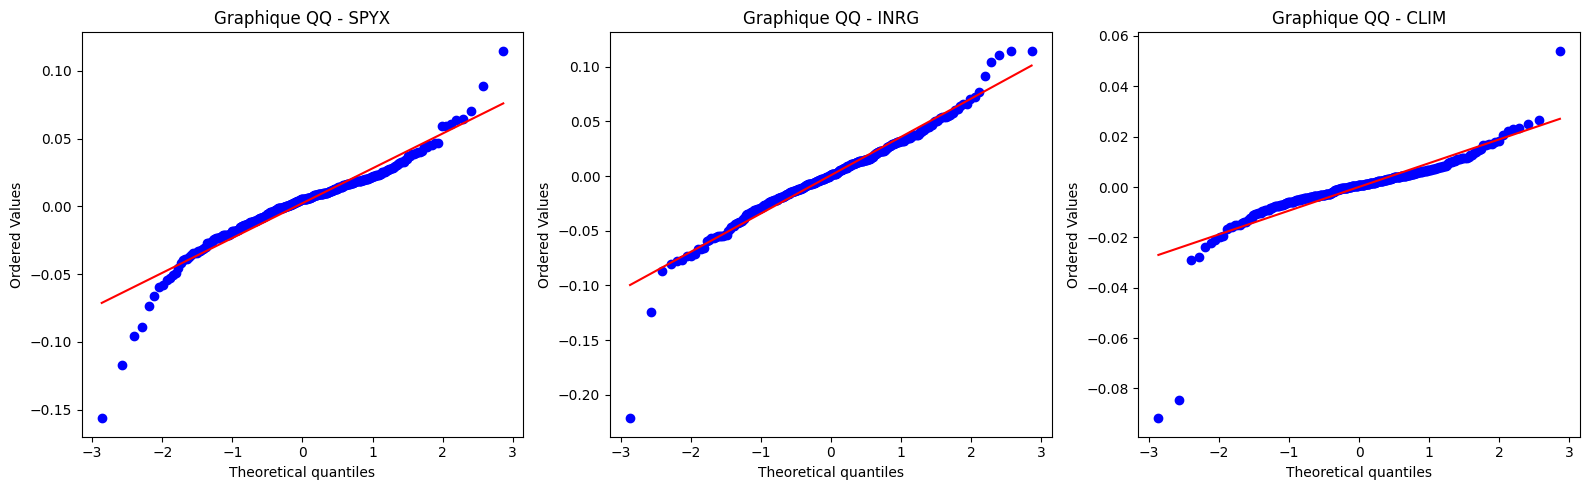

In [12]:
# Nous faisons les graphiques QQ pour chaque ETF :
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
stats.probplot(merged_data['SPYX_Log_Returns'], dist="norm", plot=plt)
plt.title('Graphique QQ - SPYX')

plt.subplot(1, 3, 2)
stats.probplot(merged_data['INRG_Log_Returns'], dist="norm", plot=plt)
plt.title('Graphique QQ - INRG')

plt.subplot(1, 3, 3)
stats.probplot(merged_data['CLIM_Log_Returns'], dist="norm", plot=plt)
plt.title('Graphique QQ - CLIM')

plt.tight_layout()
plt.show()

In [27]:
# Nous établissons une fonction pour appliquer le test de Jarque-Bera :
def test_jarque_bera(data, column_name, etf_name):
    jb_stat, jb_pvalue, skewness, kurtosis = jarque_bera(data[column_name])
    print(f"Test de Jarque-Bera pour {etf_name}:")
    print(f"  Statistique Jarque-Bera : {jb_stat:.4f}")
    print(f"  P-valeur : {jb_pvalue:.4f}")
    print(f"  Skewness : {skewness:.4f}")
    print(f"  Kurtosis : {kurtosis:.4f}")
    if jb_pvalue < 0.05:
        print(f"  Conclusion : La distribution des rendements de {etf_name} n'est PAS normale (niveau de signification de 5%).\n")
    else:
        print(f"  Conclusion : La distribution des rendements de {etf_name} est normale (niveau de signification de 5%).\n")

# Nous appliquons le test pour chaque ETF :
test_jarque_bera(merged_data, 'SPYX_Log_Returns', 'SPYX')
test_jarque_bera(merged_data, 'INRG_Log_Returns', 'INRG')
test_jarque_bera(merged_data, 'CLIM_Log_Returns', 'CLIM')


Test de Jarque-Bera pour SPYX:
  Statistique Jarque-Bera : 544.0570
  P-valeur : 0.0000
  Skewness : -0.9134
  Kurtosis : 9.0092
  Conclusion : La distribution des rendements de SPYX n'est PAS normale (niveau de signification de 5%).

Test de Jarque-Bera pour INRG:
  Statistique Jarque-Bera : 337.6838
  P-valeur : 0.0000
  Skewness : -0.6038
  Kurtosis : 7.7986
  Conclusion : La distribution des rendements de INRG n'est PAS normale (niveau de signification de 5%).

Test de Jarque-Bera pour CLIM:
  Statistique Jarque-Bera : 10354.1040
  P-valeur : 0.0000
  Skewness : -2.8819
  Kurtosis : 29.7867
  Conclusion : La distribution des rendements de CLIM n'est PAS normale (niveau de signification de 5%).



c. Matrice de corrélation entre les rendements des 3 ETFs

Matrice des corrélations entre les rendements des 3 ETFs :
                  SPYX_Log_Returns  INRG_Log_Returns  CLIM_Log_Returns
SPYX_Log_Returns          1.000000          0.461748          0.388428
INRG_Log_Returns          0.461748          1.000000          0.119800
CLIM_Log_Returns          0.388428          0.119800          1.000000


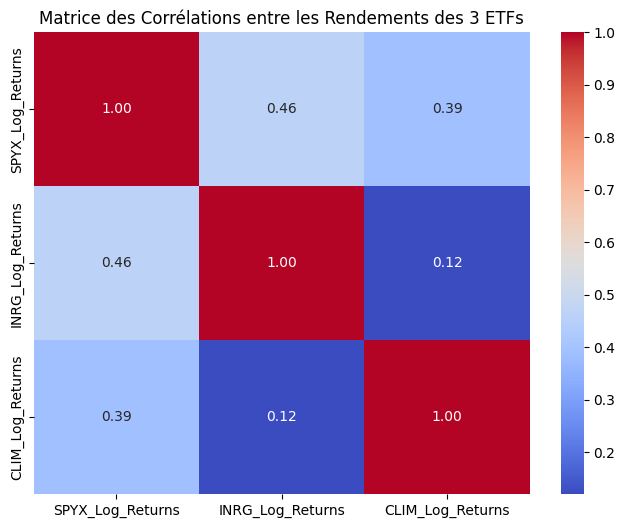

In [29]:
# Nous calculons la matrice de corrélation entre les rendements des 3 ETFs :
correlation_matrix = merged_data[['SPYX_Log_Returns', 'INRG_Log_Returns', 'CLIM_Log_Returns']].corr()

print("Matrice des corrélations entre les rendements des 3 ETFs :")
print(correlation_matrix)

# Nous présentons les résultats sous la forme d'une heatmap :
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice des Corrélations entre les Rendements des 3 ETFs")
plt.show()

d. Fonctions d’autocorrélation des rendements


<Figure size 1000x500 with 0 Axes>

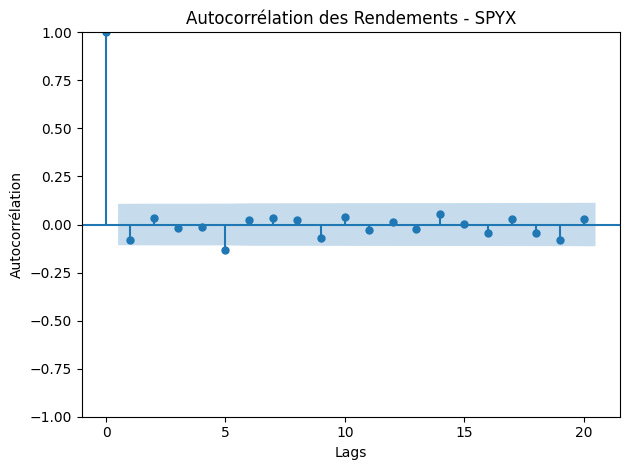

<Figure size 1000x500 with 0 Axes>

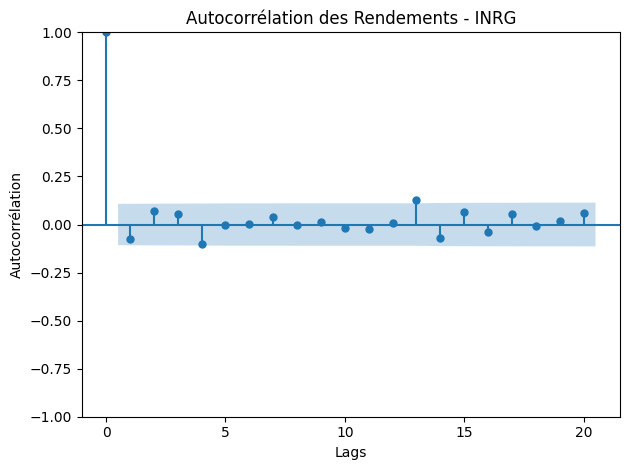

<Figure size 1000x500 with 0 Axes>

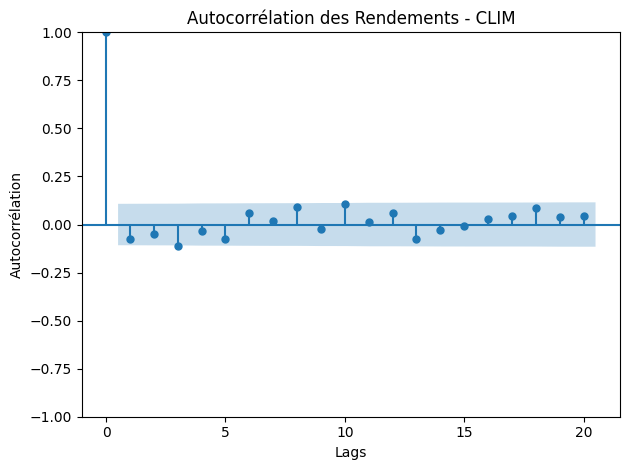

In [32]:
# Nous créons une fonction pour tracer l'autocorrélation :
def plot_autocorrelation(data, column_name, etf_name, lags=20):
    plt.figure(figsize=(10, 5))
    sm.graphics.tsa.plot_acf(data[column_name], lags=lags, alpha=0.05, title=f"Autocorrélation des Rendements - {etf_name}")
    plt.xlabel('Lags')
    plt.ylabel('Autocorrélation')
    plt.tight_layout()
    plt.show()

# Nous représentation les autocorrélations pour chaque ETF :
plot_autocorrelation(merged_data, 'SPYX_Log_Returns', 'SPYX')
plot_autocorrelation(merged_data, 'INRG_Log_Returns', 'INRG')
plot_autocorrelation(merged_data, 'CLIM_Log_Returns', 'CLIM')

Exercice 3

a. Estimation d'un modèle ARIMA(6,1,0) et représentation de l'IRF

In [35]:
# Nous avons décidé de garder SPYX et INRG :
etf_1 = 'SPYX'
etf_2 = 'INRG'

merged_data[f'{etf_1}_Log_Price'] = np.log(merged_data[etf_1])
merged_data[f'{etf_2}_Log_Price'] = np.log(merged_data[etf_2])

# Nous estimons ARIMA(6,1,0) pour SPYX :
model_1 = ARIMA(merged_data[f'{etf_1}_Log_Price'], order=(6, 1, 0))
results_1 = model_1.fit()

# Estimation ARIMA(6,1,0) pour INRG :
model_2 = ARIMA(merged_data[f'{etf_2}_Log_Price'], order=(6, 1, 0))
results_2 = model_2.fit()

print(f"Résumé du modèle ARIMA(6,1,0) pour {etf_1} :")
print(results_1.summary())
print(f"\nRésumé du modèle ARIMA(6,1,0) pour {etf_2} :")
print(results_2.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Résumé du modèle ARIMA(6,1,0) pour SPYX :
                               SARIMAX Results                                
Dep. Variable:         SPYX_Log_Price   No. Observations:                  331
Model:                 ARIMA(6, 1, 0)   Log Likelihood                 729.625
Date:                Mon, 06 Jan 2025   AIC                          -1445.250
Time:                        18:12:53   BIC                          -1418.656
Sample:                             0   HQIC                         -1434.642
                                - 331                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0712      0.042     -1.681      0.093      -0.154       0.012
ar.L2          0.0380      0.042      0.914      0.361      -0.044       0.120
ar.L3     

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


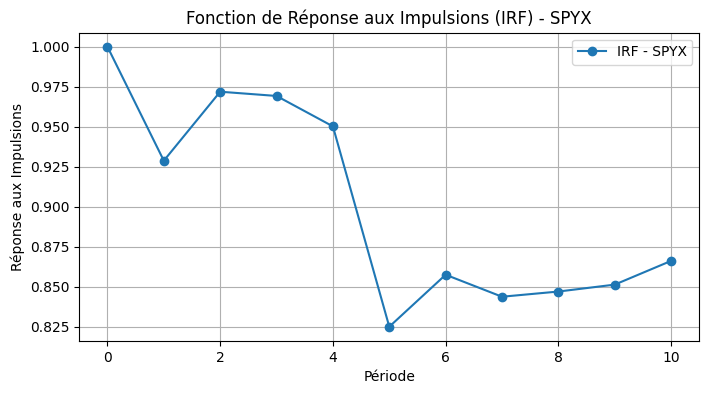

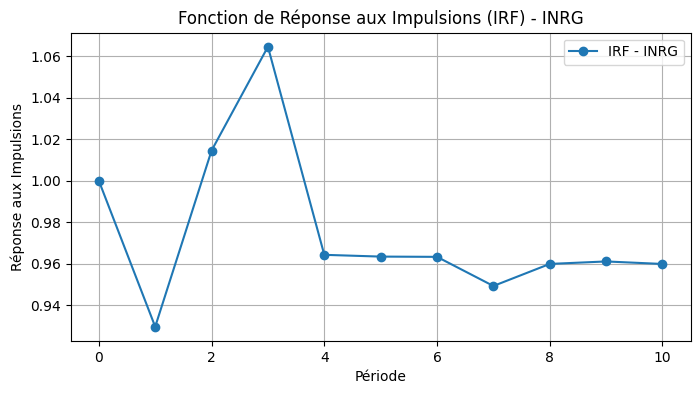

In [37]:
# Nous passons à la représentation de l'IRF :

# Fonction de réponse aux impulsions pour SPYX :
irf_1 = results_1.impulse_responses(10)
plt.figure(figsize=(8, 4))
plt.plot(irf_1, marker='o', label=f'IRF - {etf_1}')
plt.title(f"Fonction de Réponse aux Impulsions (IRF) - {etf_1}")
plt.xlabel("Période")
plt.ylabel("Réponse aux Impulsions")
plt.legend()
plt.grid()
plt.show()

# Fonction de réponse aux impulsions pour INRG :
irf_2 = results_2.impulse_responses(10)  # IRF sur 10 périodes
plt.figure(figsize=(8, 4))
plt.plot(irf_2, marker='o', label=f'IRF - {etf_2}')
plt.title(f"Fonction de Réponse aux Impulsions (IRF) - {etf_2}")
plt.xlabel("Période")
plt.ylabel("Réponse aux Impulsions")
plt.legend()
plt.grid()
plt.show()

b. Tests de racine-unitaire ADF et KPSS

In [42]:
# Test ADF pour  SPYX :
adf_1 = adfuller(merged_data[f'{etf_1}_Log_Price'].dropna())
print(f"Test ADF pour {etf_1} :")
print(f"Statistique ADF : {adf_1[0]}")
print(f"P-valeur : {adf_1[1]}")
print(f"Valeurs critiques : {adf_1[4]}\n")

# Test ADF pour INRG :
adf_2 = adfuller(merged_data[f'{etf_2}_Log_Price'].dropna())
print(f"Test ADF pour {etf_2} :")
print(f"Statistique ADF : {adf_2[0]}")
print(f"P-valeur : {adf_2[1]}")
print(f"Valeurs critiques : {adf_2[4]}\n")

Test ADF pour SPYX :
Statistique ADF : -0.3999632924535133
P-valeur : 0.9101049060293338
Valeurs critiques : {'1%': -3.4503224123605194, '5%': -2.870338478726661, '10%': -2.571457612488522}

Test ADF pour INRG :
Statistique ADF : -1.4251160933637637
P-valeur : 0.5701776913318233
Valeurs critiques : {'1%': -3.4503224123605194, '5%': -2.870338478726661, '10%': -2.571457612488522}



In [43]:
# Test KPSS pour SPYX :
kpss_1 = kpss(merged_data[f'{etf_1}_Log_Price'].dropna(), regression='c')
print(f"Test KPSS pour {etf_1} :")
print(f"Statistique KPSS : {kpss_1[0]}")
print(f"P-valeur : {kpss_1[1]}")
print(f"Valeurs critiques : {kpss_1[3]}\n")

# Test KPSS pour INRG :
kpss_2 = kpss(merged_data[f'{etf_2}_Log_Price'].dropna(), regression='c')
print(f"Test KPSS pour {etf_2} :")
print(f"Statistique KPSS : {kpss_2[0]}")
print(f"P-valeur : {kpss_2[1]}")
print(f"Valeurs critiques : {kpss_2[3]}\n")

Test KPSS pour SPYX :
Statistique KPSS : 2.539128114073474
P-valeur : 0.01
Valeurs critiques : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Test KPSS pour INRG :
Statistique KPSS : 1.5875044736362267
P-valeur : 0.01
Valeurs critiques : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}



<ipython-input-43-7d11bb6045e8>:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_1 = kpss(merged_data[f'{etf_1}_Log_Price'].dropna(), regression='c')
<ipython-input-43-7d11bb6045e8>:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_2 = kpss(merged_data[f'{etf_2}_Log_Price'].dropna(), regression='c')


c. Test de cointégration d'Engle et Granger entre SPYX et INRG

In [46]:
# Test de cointégration entre SPYX et INRG :
coint_stat, p_value, crit_values = coint(
    merged_data[f'{etf_1}_Log_Price'].dropna(),
    merged_data[f'{etf_2}_Log_Price'].dropna()
)

print(f"Test de cointégration d’Engle et Granger entre {etf_1} et {etf_2} :")
print(f"Statistique de cointégration : {coint_stat}")
print(f"P-valeur : {p_value}")
print(f"Valeurs critiques : {crit_values}")

Test de cointégration d’Engle et Granger entre SPYX et INRG :
Statistique de cointégration : 0.5609365147930587
P-valeur : 0.9930152546627743
Valeurs critiques : [-3.92993545 -3.35470811 -3.0573271 ]
